Bias-variance tradeoff, made concrete with polynomial regression at increasing degree on noisy synthetic data. Underfitting (high bias) and overfitting (high variance) visualized directly, plus a proper bias/variance decomposition via repeated resampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

def make_dataset(n=30, noise=0.3, seed=None):
    r = np.random.RandomState(seed)
    x = np.sort(r.uniform(0, 1, n))
    y = true_function(x) + r.normal(0, noise, n)
    return x, y

x, y = make_dataset(n=30, noise=0.3, seed=42)
x_plot = np.linspace(0, 1, 200)

X_train, X_test, y_train, y_test = train_test_split(x.reshape(-1, 1), y, test_size=0.3, random_state=42)

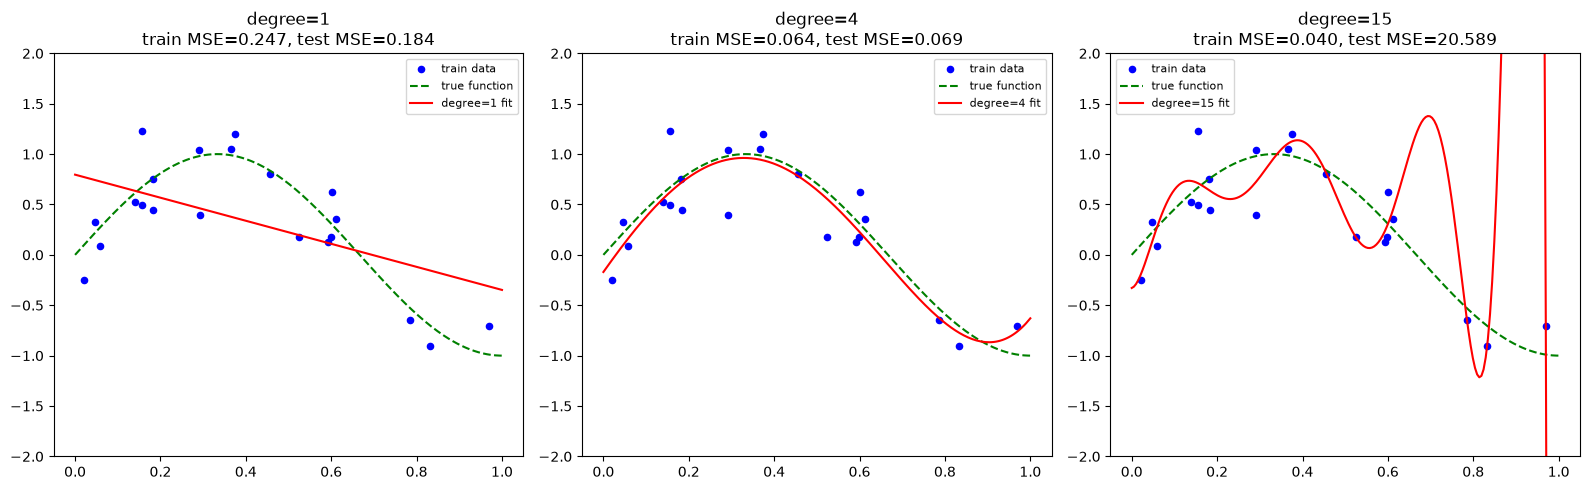

degree=1: underfits (high bias) -- too simple to capture the curve
degree=4: good fit -- captures the true shape without chasing noise
degree=15: overfits (high variance) -- wiggles to chase individual noisy points


In [2]:
degrees = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, degree in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    ax.scatter(X_train, y_train, color='blue', s=20, label='train data')
    ax.plot(x_plot, true_function(x_plot), color='green', linestyle='--', label='true function')
    ax.plot(x_plot, model.predict(x_plot.reshape(-1, 1)), color='red', label=f'degree={degree} fit')
    ax.set_ylim(-2, 2)
    train_mse = np.mean((model.predict(X_train) - y_train) ** 2)
    test_mse = np.mean((model.predict(X_test) - y_test) ** 2)
    ax.set_title(f'degree={degree}\ntrain MSE={train_mse:.3f}, test MSE={test_mse:.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("degree=1: underfits (high bias) -- too simple to capture the curve")
print("degree=4: good fit -- captures the true shape without chasing noise")
print("degree=15: overfits (high variance) -- wiggles to chase individual noisy points")

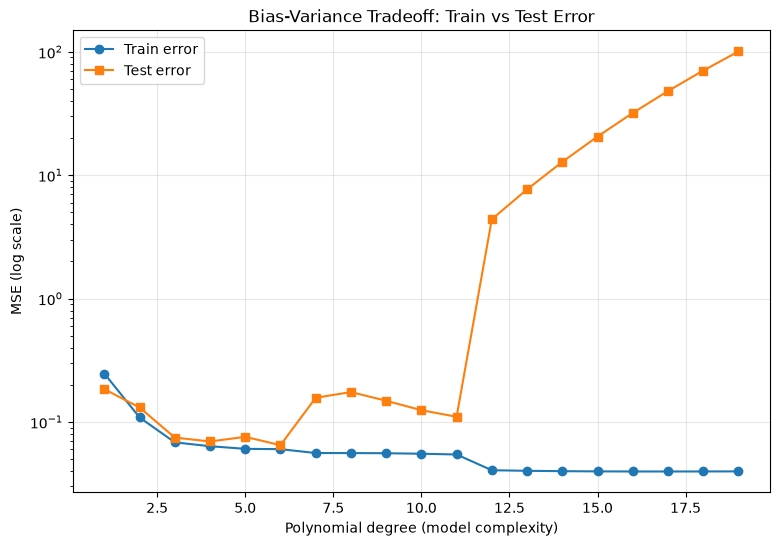

Train error always decreases with complexity. Test error decreases then increases --
the minimum of the test curve is the sweet spot between bias and variance.


In [3]:
# Train vs test error across degrees -- the classic U-shaped test error curve
degree_range = range(1, 20)
train_errors, test_errors = [], []

for d in degree_range:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)
    train_errors.append(np.mean((model.predict(X_train) - y_train) ** 2))
    test_errors.append(np.mean((model.predict(X_test) - y_test) ** 2))

plt.figure(figsize=(9, 6))
plt.plot(degree_range, train_errors, 'o-', label='Train error')
plt.plot(degree_range, test_errors, 's-', label='Test error')
plt.yscale('log')
plt.xlabel('Polynomial degree (model complexity)')
plt.ylabel('MSE (log scale)')
plt.title('Bias-Variance Tradeoff: Train vs Test Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("Train error always decreases with complexity. Test error decreases then increases --")
print("the minimum of the test curve is the sweet spot between bias and variance.")

In [4]:
# Proper bias^2 + variance decomposition: resample the training set many times,
# refit the same-degree model, and see how predictions vary at each x point.
def bias_variance_decomposition(degree, n_resamples=200, n_points=30, noise=0.3):
    x_eval = np.linspace(0.05, 0.95, 50)
    all_preds = np.zeros((n_resamples, len(x_eval)))

    for i in range(n_resamples):
        x_tr, y_tr = make_dataset(n=n_points, noise=noise, seed=i)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(x_tr.reshape(-1, 1), y_tr)
        all_preds[i] = model.predict(x_eval.reshape(-1, 1))

    mean_pred = all_preds.mean(axis=0)
    true_vals = true_function(x_eval)

    bias_sq = np.mean((mean_pred - true_vals) ** 2)
    variance = np.mean(all_preds.var(axis=0))
    return bias_sq, variance, x_eval, all_preds, mean_pred, true_vals

results = []
for d in [1, 4, 15]:
    bias_sq, variance, x_eval, all_preds, mean_pred, true_vals = bias_variance_decomposition(d)
    results.append({'degree': d, 'bias^2': bias_sq, 'variance': variance, 'bias^2 + variance': bias_sq + variance})

import pandas as pd
print(pd.DataFrame(results))

   degree    bias^2   variance  bias^2 + variance
0       1  0.146475   0.021086           0.167560
1       4  0.000195   0.016150           0.016345
2      15  0.008203  11.094813          11.103016


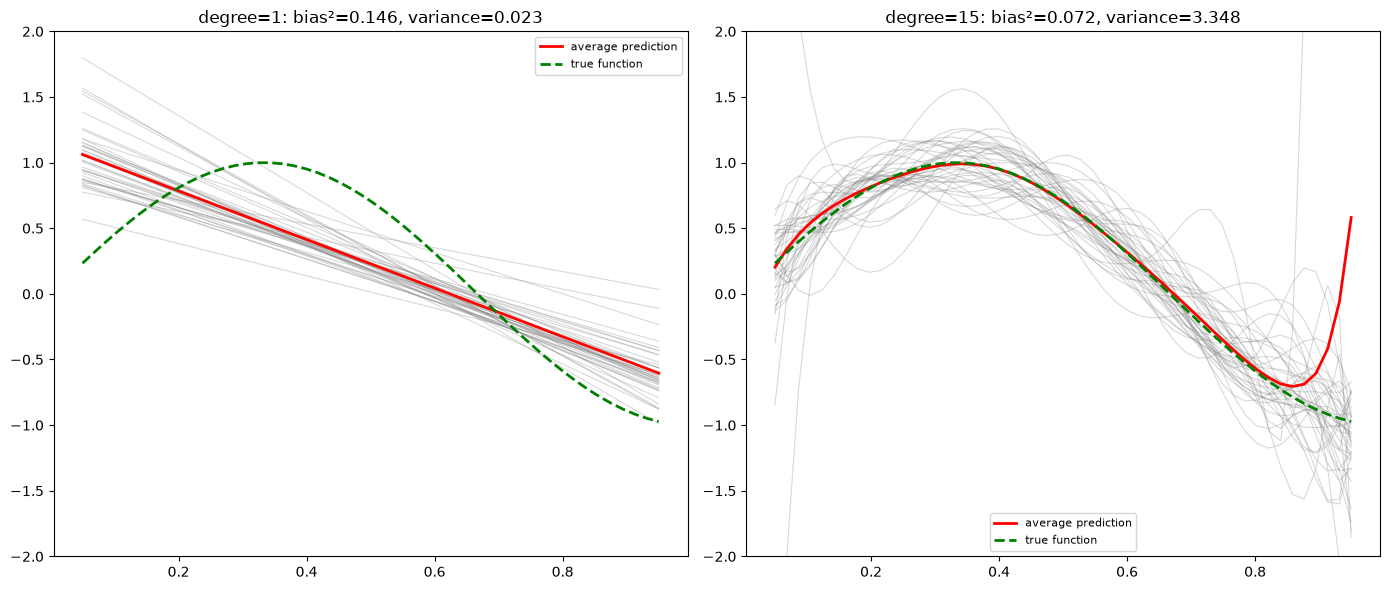

degree=1: all the gray lines (different resamples) look almost identical -- low variance, but
  the average prediction (red) misses the true curve (green) -- high bias.
degree=15: gray lines scatter wildly across resamples -- high variance -- even though their
  average might track the true curve reasonably well.


In [5]:
# Visualize variance directly: many resampled fits for a low-degree (high bias) vs
# high-degree (high variance) model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, degree in zip(axes, [1, 15]):
    bias_sq, variance, x_eval, all_preds, mean_pred, true_vals = bias_variance_decomposition(degree, n_resamples=40)
    for pred in all_preds:
        ax.plot(x_eval, pred, color='gray', alpha=0.3, linewidth=0.8)
    ax.plot(x_eval, mean_pred, color='red', linewidth=2, label='average prediction')
    ax.plot(x_eval, true_vals, color='green', linestyle='--', linewidth=2, label='true function')
    ax.set_ylim(-2, 2)
    ax.set_title(f'degree={degree}: bias²={bias_sq:.3f}, variance={variance:.3f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("degree=1: all the gray lines (different resamples) look almost identical -- low variance, but")
print("  the average prediction (red) misses the true curve (green) -- high bias.")
print("degree=15: gray lines scatter wildly across resamples -- high variance -- even though their")
print("  average might track the true curve reasonably well.")